# Exploratory Data Analysis (EDA)
## Employee Attrition & Performance Dataset

---

This notebook performs a comprehensive exploratory analysis of the employee attrition and performance dataset.

### Table of Contents:
1. Import Libraries and Load Data
2. Initial Dataset Exploration
3. Null Values and Data Types Analysis
4. Descriptive Statistics
5. Univariate Analysis - Categorical Variables
6. Univariate Analysis - Numerical Variables
7. Target Variable Analysis (Attrition)
8. Correlation Analysis
9. Bivariate Analysis
10. Insights and Conclusions


## 1. Import Libraries and Load Data


In [1]:
# Main libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Pandas settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")


Libraries loaded successfully


In [2]:
# Load the dataset
df = pd.read_csv('employee_attrition_performance.csv')

print(f"Dataset loaded successfully")
print(f"Dimensions: {df.shape[0]:,} rows x {df.shape[1]} columns")


Dataset loaded successfully
Dimensions: 10,000 rows x 22 columns


## 2. Initial Dataset Exploration

In [ ]:
# First rows of the dataset
print("First 10 rows of the dataset:")
df.head(10)

First 10 rows of the dataset:


,employee_id,age,gender,education,department,job_role,monthly_salary,years_at_company,years_in_current_role,performance_score,job_satisfaction,work_life_balance,overtime,distance_from_home_km,num_projects_last_year,training_hours_last_year,num_promotions,last_promotion_years_ago,stock_option_level,relationship_satisfaction,environment_satisfaction,attrition
0,EMP00001,42,Female,Master,Finance,Role_22,107433,2,0,3.40,3.20,3,Yes,11,3,21,0,1,0,1,4,No
1,EMP00002,35,Male,Master,HR,Role_8,77660,4,0,3.40,3.40,2,Yes,30,4,29,1,2,0,3,3,No
2,EMP00003,40,Male,PhD,Legal,Role_1,114377,3,0,4.10,3.60,3,No,10,2,72,0,3,2,4,4,Yes
3,EMP00004,35,Male,High School,R&D,Role_15,79284,2,1,2.90,3.00,3,No,9,6,24,0,0,0,3,3,No
4,EMP00005,47,Male,Bachelor,Finance,Role_11,95933,1,1,3.30,3.30,3,No,10,2,52,0,0,3,2,3,No
5,EMP00006,29,Male,Bachelor,Operations,Role_49,59214,0,0,3.00,3.60,3,No,13,5,36,0,0,1,3,3,No
6,EMP00007,57,Female,Bachelor,R&D,Role_36,117285,1,0,2.40,2.30,3,No,8,3,67,0,1,0,3,3,Yes
7,EMP00008,30,Female,PhD,Operations,Role_49,94650,1,0,3.50,1.50,4,No,9,6,42,0,0,1,1,2,No
8,EMP00009,56,Other,Master,Engineering,Role_8,115248,0,0,3.70,1.80,3,No,13,4,39,0,0,0,4,2,No
9,EMP00010,38,Male,Bachelor,HR,Role_3,67594,1,0,3.30,3.50,4,No,9,3,50,0,1,0,3,4,No


In [ ]:
# General dataset information
print("Dataset Information:")
print("="*60)
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   employee_id                10000 non-null  object 
 1   age                        10000 non-null  int64  
 2   gender                     10000 non-null  object 
 3   education                  10000 non-null  object 
 4   department                 10000 non-null  object 
 5   job_role                   10000 non-null  object 
 6   monthly_salary             10000 non-null  int64  
 7   years_at_company           10000 non-null  int64  
 8   years_in_current_role      10000 non-null  int64  
 9   performance_score          10000 non-null  float64
 10  job_satisfaction           10000 non-null  float64
 11  work_life_balance          10000 non-null  int64  
 12  overtime                   10000 non-null  object 
 13  distance_from_home_km     

In [ ]:
# List of columns with their data types
print("Dataset Columns:")
print("="*60)
for i, (col, dtype) in enumerate(zip(df.columns, df.dtypes), 1):
    print(f"{i:2}. {col:30} -> {dtype}")

Dataset Columns:
 1. employee_id                    -> object
 2. age                            -> int64
 3. gender                         -> object
 4. education                      -> object
 5. department                     -> object
 6. job_role                       -> object
 7. monthly_salary                 -> int64
 8. years_at_company               -> int64
 9. years_in_current_role          -> int64
10. performance_score              -> float64
11. job_satisfaction               -> float64
12. work_life_balance              -> int64
13. overtime                       -> object
14. distance_from_home_km          -> int64
15. num_projects_last_year         -> int64
16. training_hours_last_year       -> int64
17. num_promotions                 -> int64
18. last_promotion_years_ago       -> int64
19. stock_option_level             -> int64
20. relationship_satisfaction      -> int64
21. environment_satisfaction       -> int64
22. attrition                      -> object


## 3. Null Values and Data Types Analysis

In [6]:
# Null values analysis
null_analysis = pd.DataFrame({
    'Column': df.columns,
    'Null Values': df.isnull().sum().values,
    'Percentage (%)': (df.isnull().sum().values / len(df) * 100).round(2),
    'Unique Values': df.nunique().values,
    'Data Type': df.dtypes.values
})

print("Null Values and Data Analysis:")
print("="*80)
null_analysis


Null Values and Data Analysis:


,Column,Null Values,Percentage (%),Unique Values,Data Type
0,employee_id,0,0.00,10000,object
1,age,0,0.00,44,int64
2,gender,0,0.00,3,object
3,education,0,0.00,4,object
4,department,0,0.00,8,object
5,job_role,0,0.00,49,object
6,monthly_salary,0,0.00,9274,int64
7,years_at_company,0,0.00,29,int64
8,years_in_current_role,0,0.00,16,int64
9,performance_score,0,0.00,35,float64


In [7]:
# Check duplicates and null summary
duplicates = df.duplicated().sum()
print(f"Duplicated rows: {duplicates}")

if duplicates > 0:
    print(f"   Percentage of duplicates: {(duplicates/len(df)*100):.2f}%")
else:
    print("No duplicated rows in the dataset.")

if df.isnull().sum().sum() == 0:
    print("Excellent! No null values in the dataset.")


Duplicated rows: 0
No duplicated rows in the dataset.
Excellent! No null values in the dataset.


## 4. Descriptive Statistics

In [8]:
# Identify numeric and categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remove employee_id from lists
if 'employee_id' in categorical_cols:
    categorical_cols.remove('employee_id')

print(f"Numeric Variables ({len(numeric_cols)}):")
print(f"   {numeric_cols}")
print(f"\nCategorical Variables ({len(categorical_cols)}):")
print(f"   {categorical_cols}")


Numeric Variables (15):
   ['age', 'monthly_salary', 'years_at_company', 'years_in_current_role', 'performance_score', 'job_satisfaction', 'work_life_balance', 'distance_from_home_km', 'num_projects_last_year', 'training_hours_last_year', 'num_promotions', 'last_promotion_years_ago', 'stock_option_level', 'relationship_satisfaction', 'environment_satisfaction']

Categorical Variables (6):
   ['gender', 'education', 'department', 'job_role', 'overtime', 'attrition']


In [ ]:
# Descriptive statistics for numeric variables
print("Descriptive Statistics - Numeric Variables:")
print("="*100)
df[numeric_cols].describe().T.round(2)

Descriptive Statistics - Numeric Variables:


,count,mean,std,min,25%,50%,75%,max
age,10000.00,37.85,9.50,22.00,31.00,37.00,45.00,65.00
monthly_salary,10000.00,85422.33,18519.44,38957.00,72177.75,84043.50,97020.00,163489.00
years_at_company,10000.00,3.82,4.13,0.00,1.00,3.00,6.00,33.00
years_in_current_role,10000.00,1.30,1.76,0.00,0.00,1.00,2.00,15.00
performance_score,10000.00,3.44,0.53,1.40,3.10,3.40,3.80,5.00
job_satisfaction,10000.00,3.17,0.96,1.00,2.50,3.20,3.90,5.00
work_life_balance,10000.00,2.95,0.80,1.00,3.00,3.00,3.00,4.00
distance_from_home_km,10000.00,10.62,10.21,1.00,3.00,7.00,14.00,107.00
num_projects_last_year,10000.00,4.02,1.95,1.00,3.00,4.00,5.00,10.00
training_hours_last_year,10000.00,39.80,19.60,0.00,26.00,40.00,53.00,119.00


In [ ]:
# Extended statistics: skewness and kurtosis
stats_extended = pd.DataFrame({
    'Mean': df[numeric_cols].mean(),
    'Median': df[numeric_cols].median(),
    'Std Dev': df[numeric_cols].std(),
    'Skewness': df[numeric_cols].skew(),
    'Kurtosis': df[numeric_cols].kurtosis(),
    'Min': df[numeric_cols].min(),
    'Max': df[numeric_cols].max(),
    'Range': df[numeric_cols].max() - df[numeric_cols].min()
}).round(2)

print("Extended Statistics:")
print("="*100)
stats_extended

Extended Statistics:


,Mean,Median,Std Dev,Skewness,Kurtosis,Min,Max,Range
age,37.85,37.00,9.50,0.24,-0.48,22.00,65.00,43.00
monthly_salary,85422.33,84043.50,18519.44,0.43,0.10,38957.00,163489.00,124532.00
years_at_company,3.82,3.00,4.13,1.61,3.13,0.00,33.00,33.00
years_in_current_role,1.30,1.00,1.76,2.05,5.80,0.00,15.00,15.00
performance_score,3.44,3.40,0.53,-0.03,-0.08,1.40,5.00,3.60
job_satisfaction,3.17,3.20,0.96,-0.09,-0.54,1.00,5.00,4.00
work_life_balance,2.95,3.00,0.80,-0.49,-0.15,1.00,4.00,3.00
distance_from_home_km,10.62,7.00,10.21,2.03,6.25,1.00,107.00,106.00
num_projects_last_year,4.02,4.00,1.95,0.51,-0.08,1.00,10.00,9.00
training_hours_last_year,39.80,40.00,19.60,0.09,-0.29,0.00,119.00,119.00


## 5. Univariate Analysis - Categorical Variables


In [11]:
# Categorical variables distribution
print("Categorical Variables Distribution:")
print("="*60)

for col in categorical_cols:
    print(f"\n> {col}:")
    value_counts = df[col].value_counts()
    percentages = df[col].value_counts(normalize=True) * 100
    
    summary = pd.DataFrame({
        'Frequency': value_counts,
        'Percentage (%)': percentages.round(2)
    })
    print(summary.to_string())


Categorical Variables Distribution:

> gender:
        Frequency  Percentage (%)
gender                           
Male         4869           48.69
Female       4724           47.24
Other         407            4.07

> education:
             Frequency  Percentage (%)
education                             
Bachelor          4526           45.26
Master            3016           30.16
High School       1477           14.77
PhD                981            9.81

> department:
             Frequency  Percentage (%)
department                            
Engineering       1272           12.72
HR                1271           12.71
Finance           1269           12.69
Operations        1259           12.59
Legal             1242           12.42
R&D               1232           12.32
Sales             1232           12.32
Marketing         1223           12.23

> job_role:
          Frequency  Percentage (%)
job_role                           
Role_19         239            2.39
Role_48  

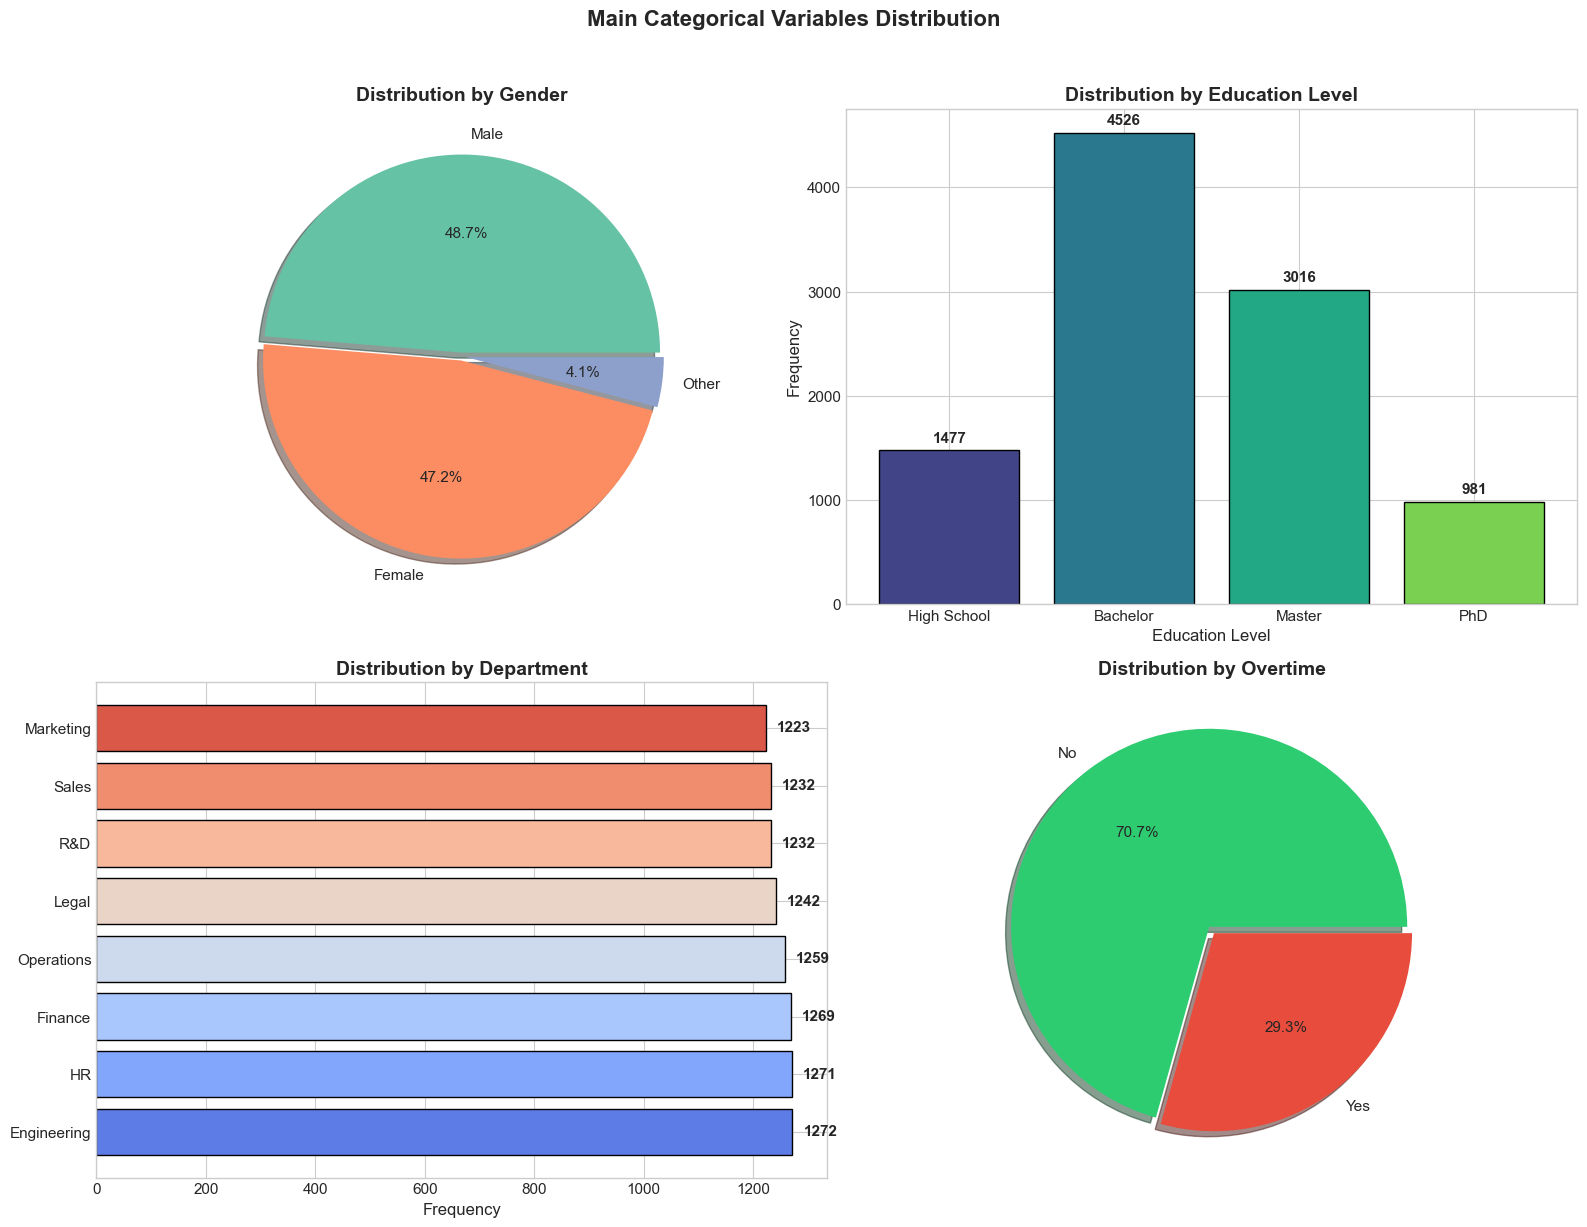

In [12]:
# Main categorical variables visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gender
ax1 = axes[0, 0]
gender_counts = df['gender'].value_counts()
colors = sns.color_palette('Set2', len(gender_counts))
wedges, texts, autotexts = ax1.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
                                    colors=colors, explode=[0.02]*len(gender_counts), shadow=True)
ax1.set_title('Distribution by Gender', fontsize=14, fontweight='bold')

# Education
ax2 = axes[0, 1]
edu_order = ['High School', 'Bachelor', 'Master', 'PhD']
edu_counts = df['education'].value_counts().reindex(edu_order)
bars = ax2.bar(edu_counts.index, edu_counts.values, color=sns.color_palette('viridis', len(edu_counts)), edgecolor='black')
ax2.set_title('Distribution by Education Level', fontsize=14, fontweight='bold')
ax2.set_xlabel('Education Level')
ax2.set_ylabel('Frequency')
for bar in bars:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             f'{int(bar.get_height())}', ha='center', va='bottom', fontweight='bold')

# Department
ax3 = axes[1, 0]
dept_counts = df['department'].value_counts()
bars = ax3.barh(dept_counts.index, dept_counts.values, color=sns.color_palette('coolwarm', len(dept_counts)), edgecolor='black')
ax3.set_title('Distribution by Department', fontsize=14, fontweight='bold')
ax3.set_xlabel('Frequency')
for bar in bars:
    ax3.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2, 
             f'{int(bar.get_width())}', ha='left', va='center', fontweight='bold')

# Overtime
ax4 = axes[1, 1]
overtime_counts = df['overtime'].value_counts()
colors_ot = ['#2ecc71', '#e74c3c']
wedges, texts, autotexts = ax4.pie(overtime_counts, labels=['No', 'Yes'] if overtime_counts.index[0] == 'No' else ['Yes', 'No'], 
                                    autopct='%1.1f%%', colors=colors_ot, explode=[0.02, 0.02], shadow=True)
ax4.set_title('Distribution by Overtime', fontsize=14, fontweight='bold')

plt.suptitle('Main Categorical Variables Distribution', y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## 6. Univariate Analysis - Numerical Variables

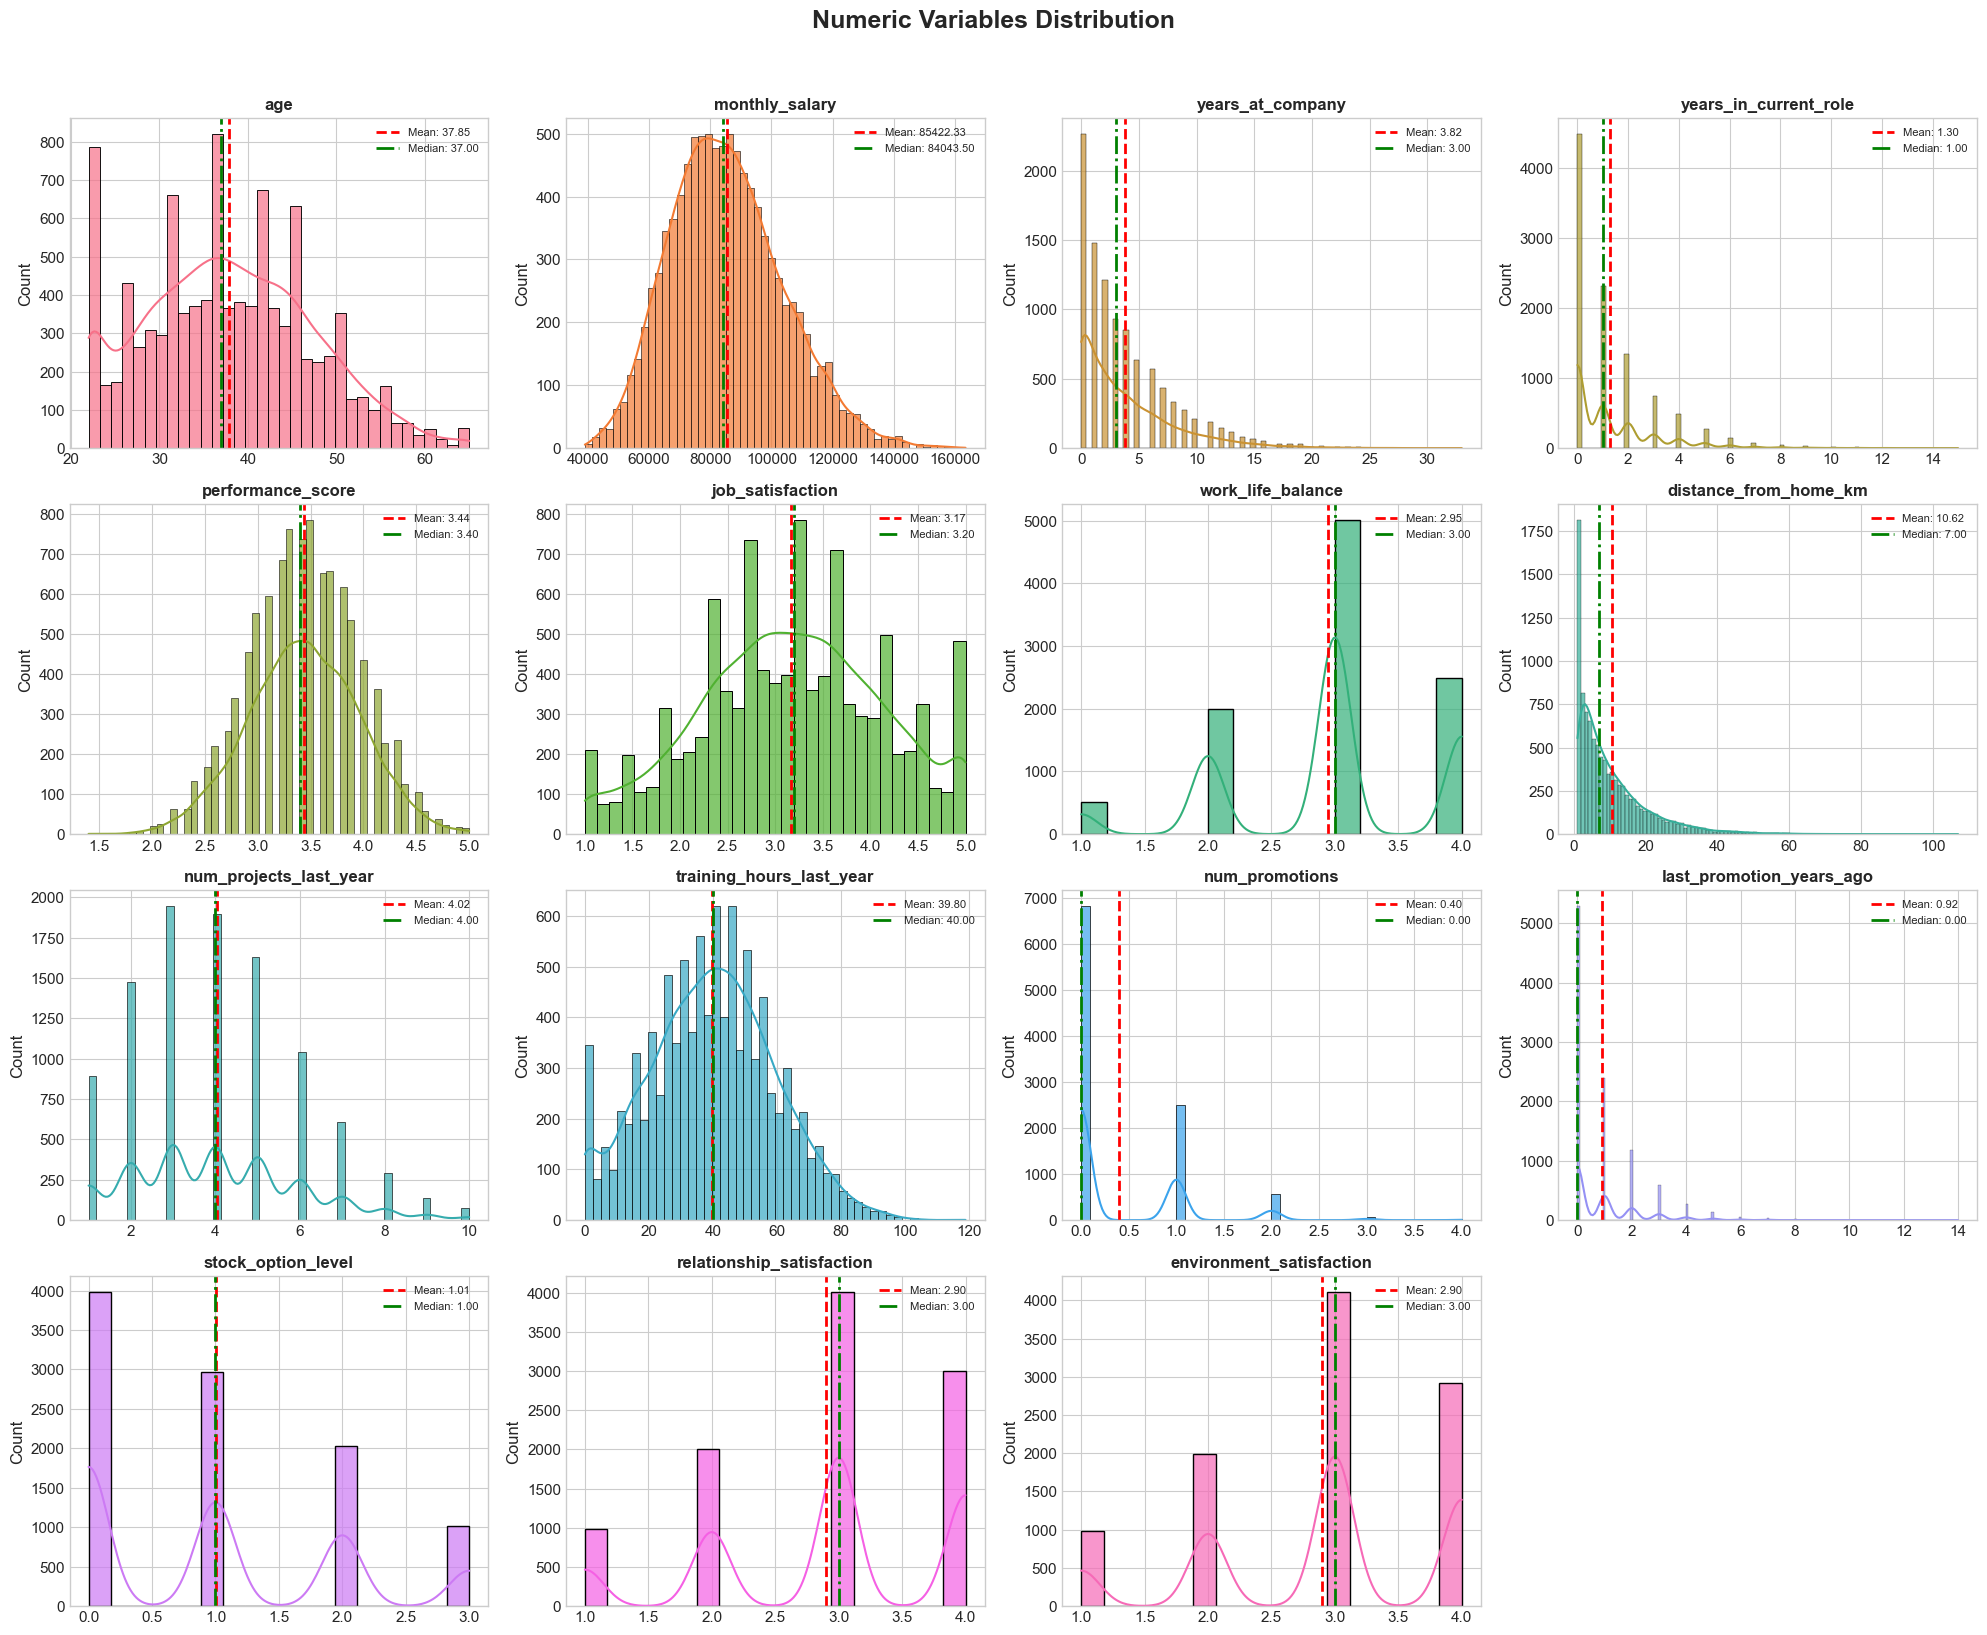

In [13]:
# Histograms of all numeric variables
n_cols = 4
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    sns.histplot(df[col], kde=True, ax=ax, color=sns.color_palette('husl', len(numeric_cols))[i], 
                 edgecolor='black', alpha=0.7)
    
    mean_val = df[col].mean()
    median_val = df[col].median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    ax.axvline(median_val, color='green', linestyle='-.', linewidth=2, label=f'Median: {median_val:.2f}')
    
    ax.set_title(f'{col}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xlabel('')

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Variables Distribution', y=1.02, fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()


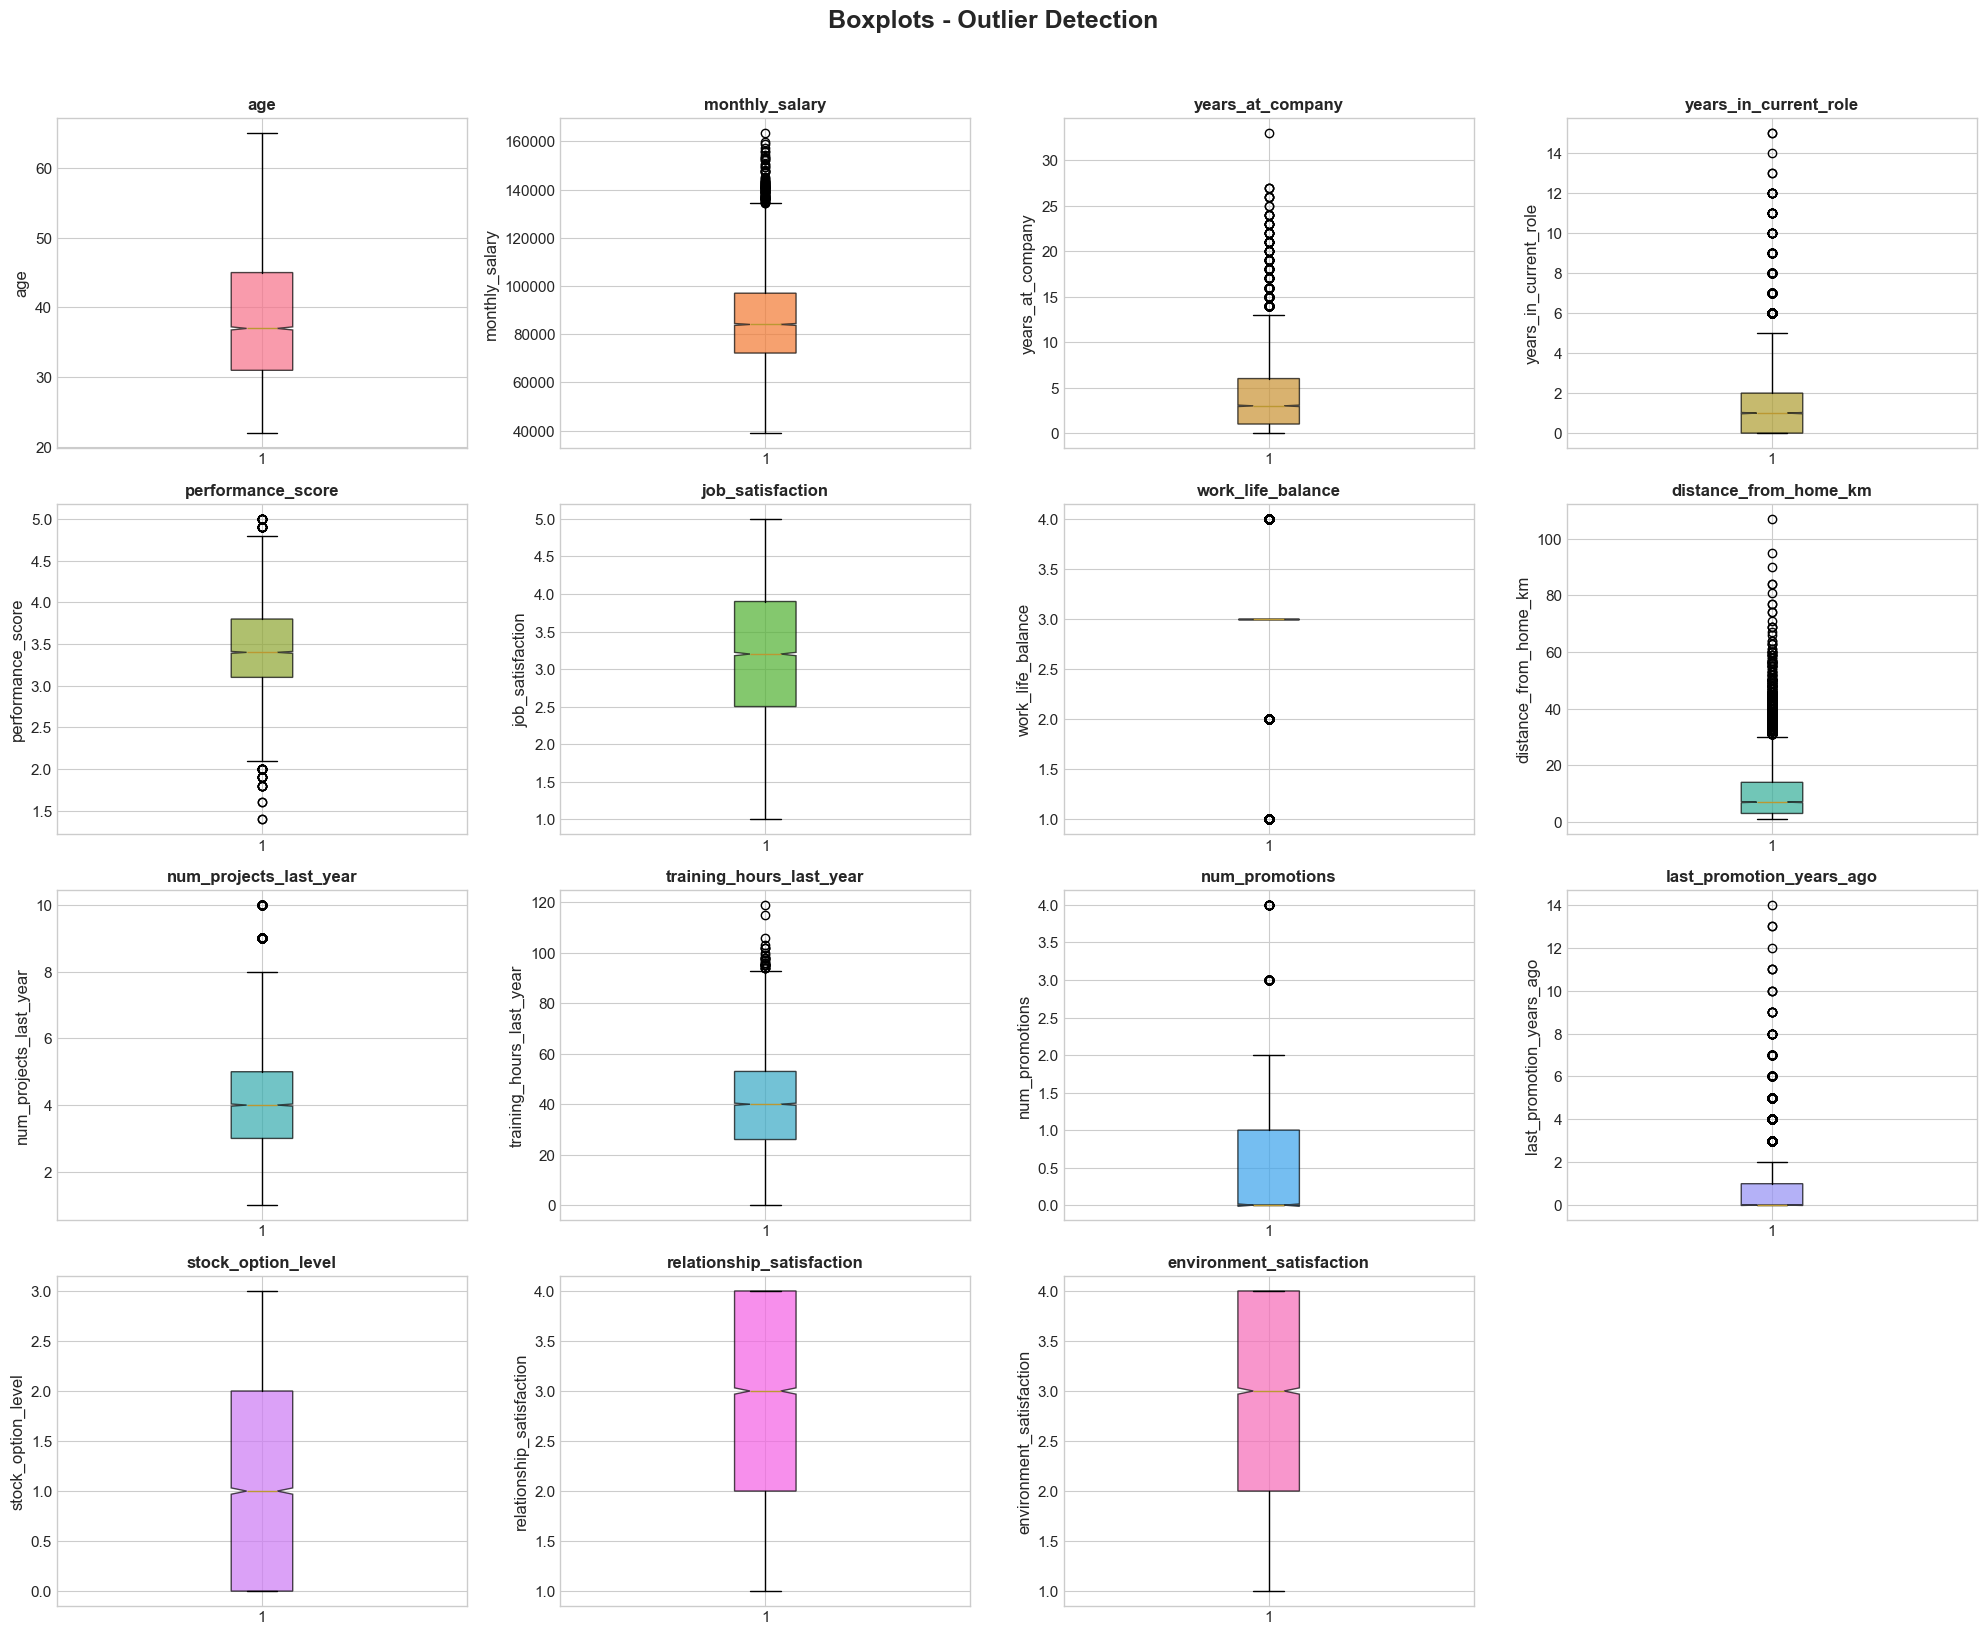

In [14]:
# Boxplots for outlier detection
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    bp = ax.boxplot(df[col].dropna(), patch_artist=True, notch=True)
    bp['boxes'][0].set_facecolor(sns.color_palette('husl', len(numeric_cols))[i])
    bp['boxes'][0].set_alpha(0.7)
    ax.set_title(f'{col}', fontsize=12, fontweight='bold')
    ax.set_ylabel(col)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots - Outlier Detection', y=1.02, fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()


## 7. Target Variable Analysis (Attrition)

In [16]:
print("Attrition Distribution (Target Variable):")
print("="*60)

attrition_counts = df['attrition'].value_counts()
attrition_pct = df['attrition'].value_counts(normalize=True) * 100

attrition_summary = pd.DataFrame({
    'Frequency': attrition_counts,
    'Percentage (%)': attrition_pct.round(2)
})
print(attrition_summary)
print(f"\nAttrition Rate: {attrition_pct['Yes']:.2f}%")


Attrition Distribution (Target Variable):
           Frequency  Percentage (%)
attrition                           
No              8600           86.00
Yes             1400           14.00

Attrition Rate: 14.00%


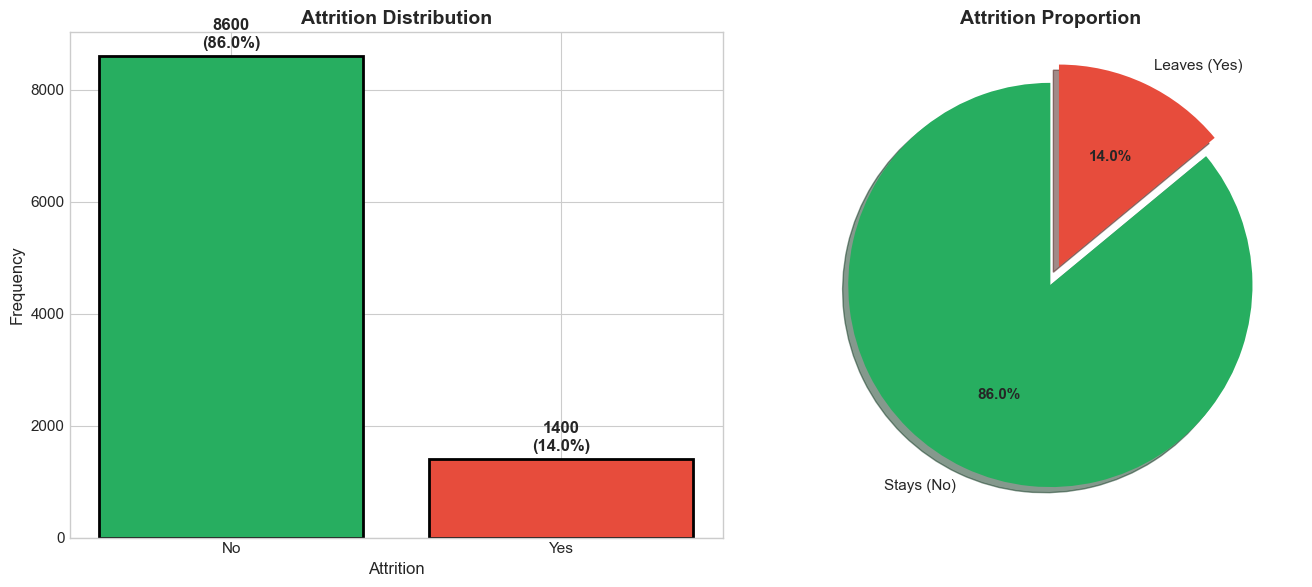


Imbalance ratio: 6.14:1
   Consider using techniques like SMOTE, undersampling, or class weights.


In [17]:
# Target variable visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart
ax1 = axes[0]
colors = ['#27ae60', '#e74c3c']
bars = ax1.bar(attrition_counts.index, attrition_counts.values, color=colors, edgecolor='black', linewidth=2)
ax1.set_title('Attrition Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Attrition')
ax1.set_ylabel('Frequency')

for bar, pct in zip(bars, attrition_pct.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, 
             f'{int(bar.get_height())}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Pie chart
ax2 = axes[1]
explode = (0, 0.1)
wedges, texts, autotexts = ax2.pie(attrition_counts, labels=['Stays (No)', 'Leaves (Yes)'], 
                                    autopct='%1.1f%%', colors=colors, explode=explode, 
                                    shadow=True, startangle=90)
autotexts[0].set_fontweight('bold')
autotexts[1].set_fontweight('bold')
ax2.set_title('Attrition Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Check class balance
imbalance_ratio = attrition_counts.max() / attrition_counts.min()
print(f"\nImbalance ratio: {imbalance_ratio:.2f}:1")
if imbalance_ratio > 3:
    print("WARNING: The dataset shows significant class imbalance.")
    print("   Consider using techniques like SMOTE, undersampling, or class weights.")
else:
    print("The dataset has acceptable class balance.")


## 8. Correlation Analysis


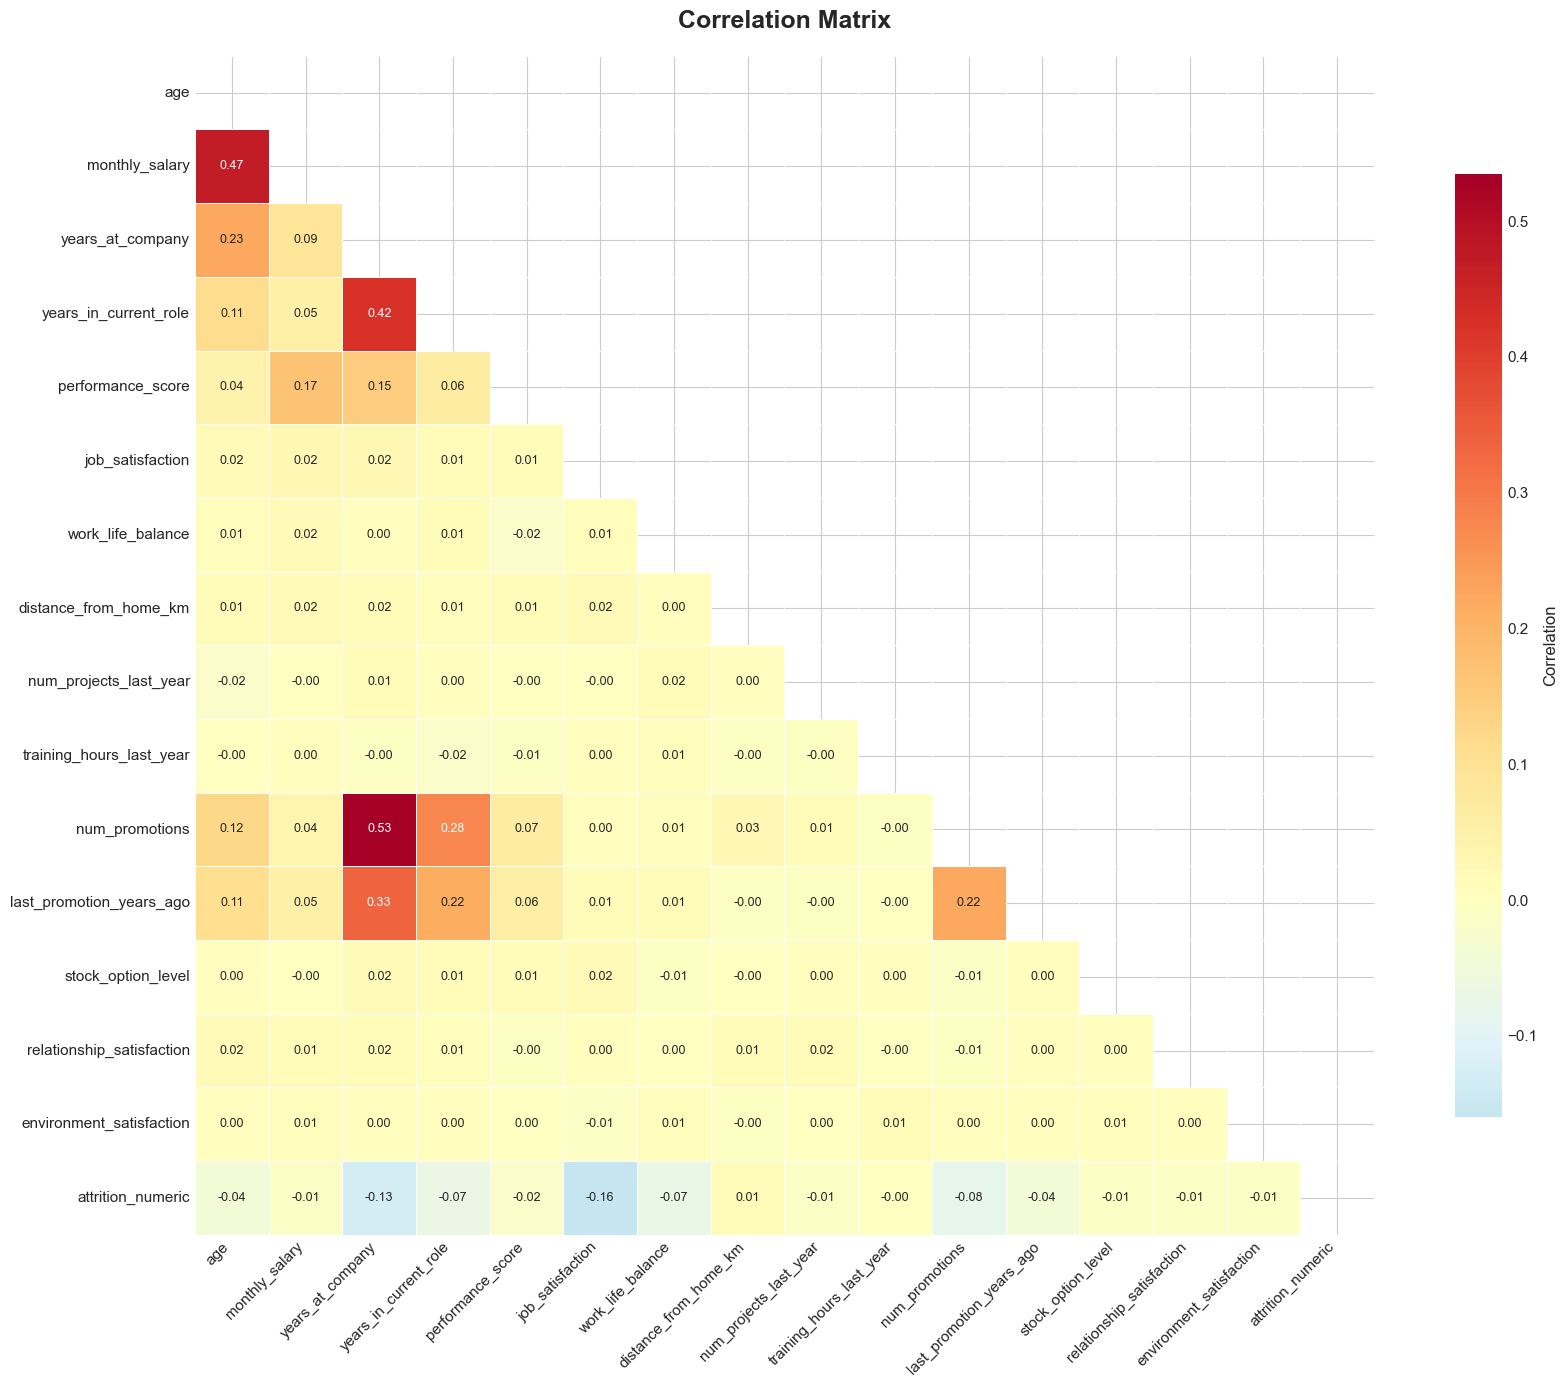

In [18]:
# Create numeric variable for attrition
df['attrition_numeric'] = df['attrition'].map({'Yes': 1, 'No': 0})

# Calculate correlation matrix
numeric_cols_with_target = numeric_cols + ['attrition_numeric']
correlation_matrix = df[numeric_cols_with_target].corr()

# Correlation heatmap
fig, ax = plt.subplots(figsize=(18, 14))

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Correlation'},
            annot_kws={'size': 9})

ax.set_title('Correlation Matrix', fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


Correlations with Attrition (sorted by magnitude):


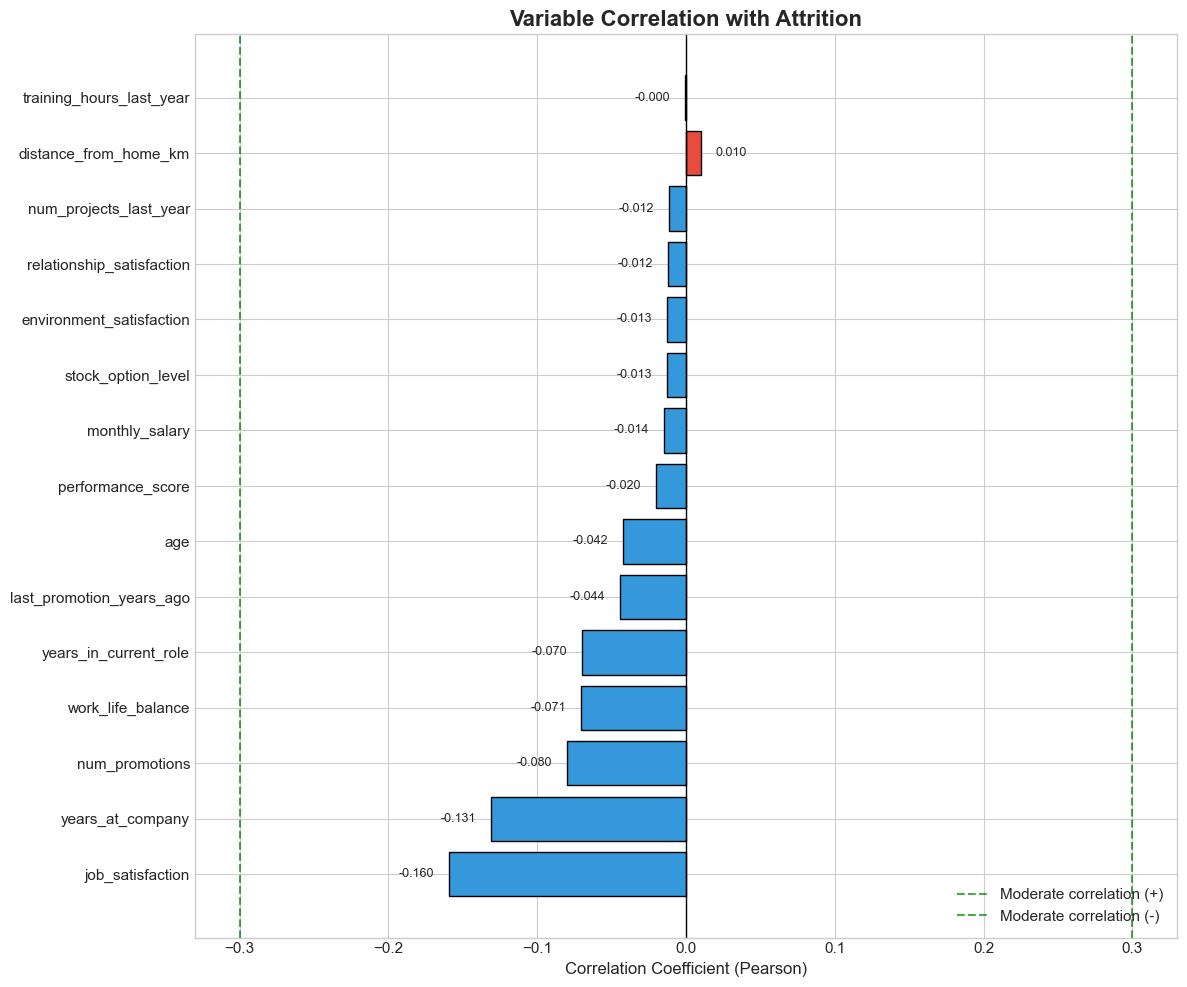


Correlation Table:


,Variable,Correlation
0,job_satisfaction,-0.16
1,years_at_company,-0.13
2,num_promotions,-0.08
3,work_life_balance,-0.07
4,years_in_current_role,-0.07
5,last_promotion_years_ago,-0.04
6,age,-0.04
7,performance_score,-0.02
8,monthly_salary,-0.01
9,stock_option_level,-0.01


In [19]:
# Correlations with target variable (Attrition)
target_correlations = correlation_matrix['attrition_numeric'].drop('attrition_numeric').sort_values(key=abs, ascending=False)

print("Correlations with Attrition (sorted by magnitude):")
print("="*60)

fig, ax = plt.subplots(figsize=(12, 10))

colors = ['#e74c3c' if x > 0 else '#3498db' for x in target_correlations.values]
bars = ax.barh(target_correlations.index, target_correlations.values, color=colors, edgecolor='black')

ax.axvline(x=0, color='black', linewidth=1)
ax.axvline(x=0.3, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='Moderate correlation (+)')
ax.axvline(x=-0.3, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='Moderate correlation (-)')

ax.set_xlabel('Correlation Coefficient (Pearson)')
ax.set_title('Variable Correlation with Attrition', fontsize=16, fontweight='bold')
ax.legend(loc='lower right')

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.01 if width >= 0 else width - 0.01, 
            bar.get_y() + bar.get_height()/2, 
            f'{width:.3f}', ha='left' if width >= 0 else 'right', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Show table
print("\nCorrelation Table:")
pd.DataFrame({'Variable': target_correlations.index, 'Correlation': target_correlations.values}).round(3)


## 9. Bivariate Analysis

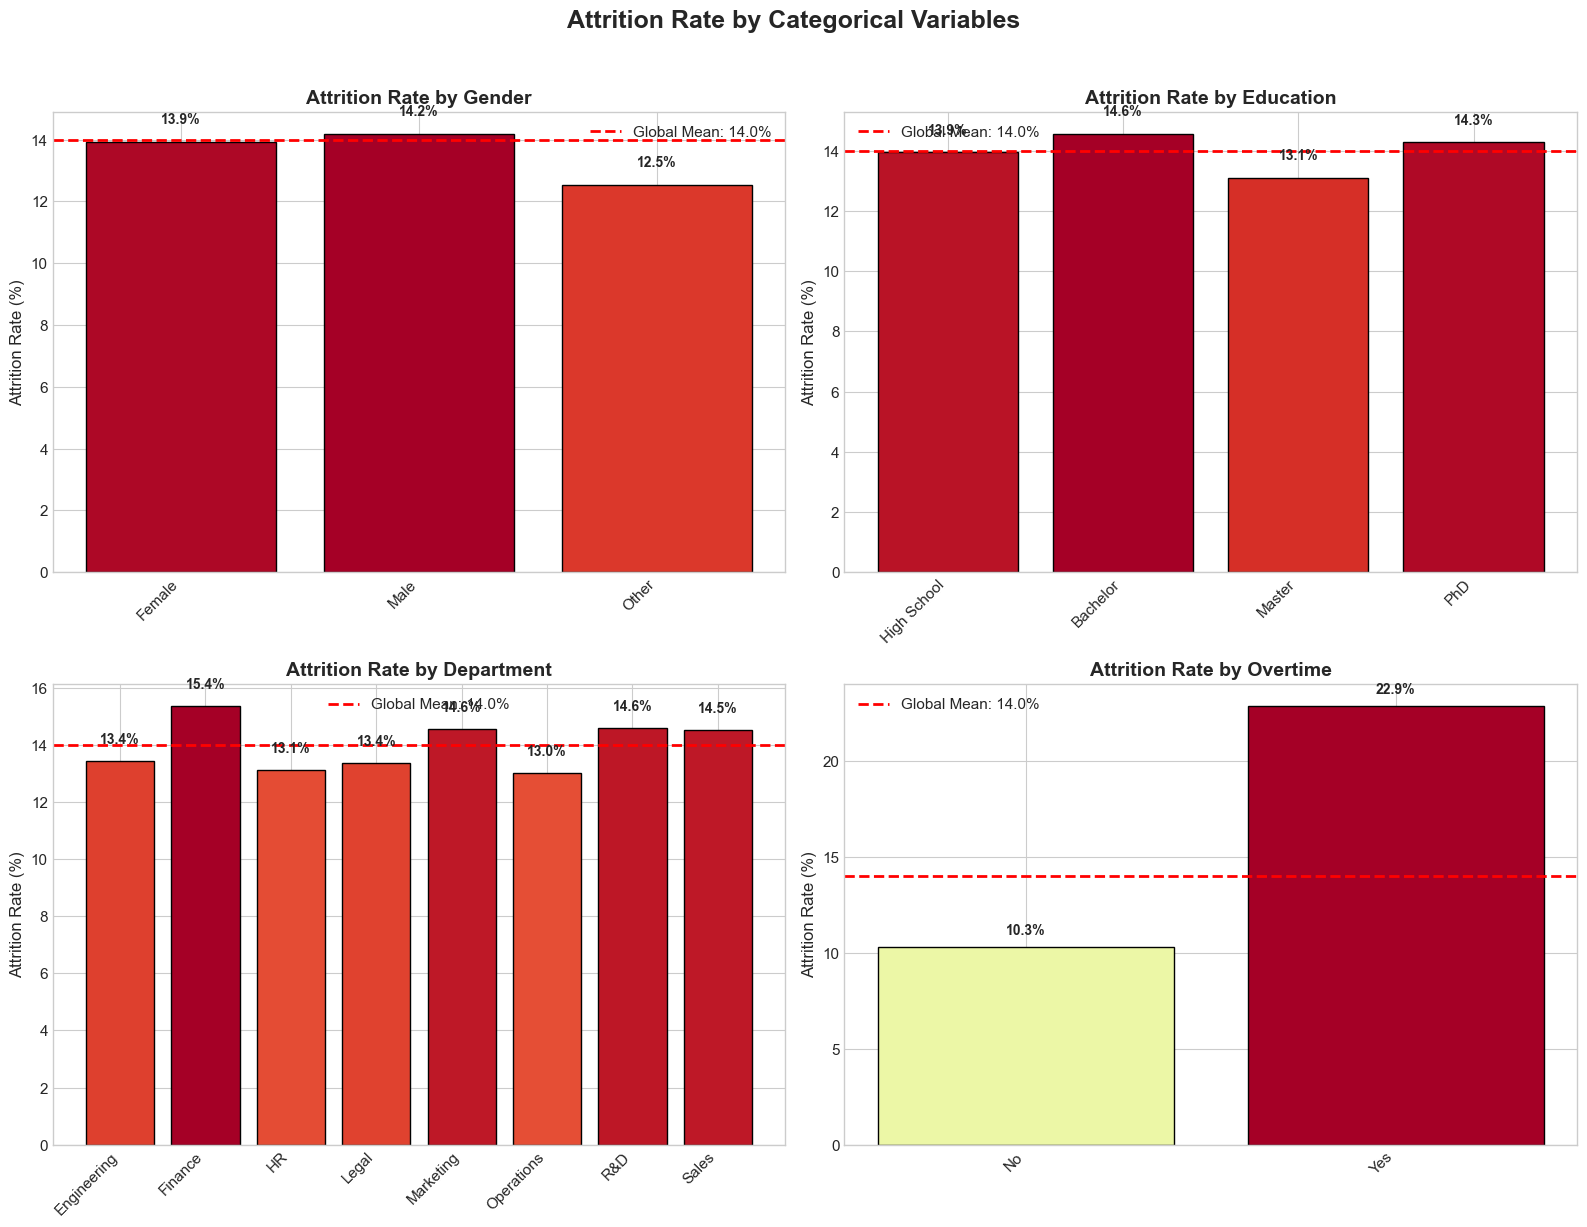

In [20]:
# Attrition by main categorical variables
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

categorical_for_analysis = ['gender', 'education', 'department', 'overtime']

for ax, col in zip(axes.flatten(), categorical_for_analysis):
    # Calculate attrition rates
    attrition_rate = df.groupby(col)['attrition_numeric'].mean() * 100
    
    if col == 'education':
        order = ['High School', 'Bachelor', 'Master', 'PhD']
        attrition_rate = attrition_rate.reindex(order)
    
    colors = plt.cm.RdYlGn_r(attrition_rate / attrition_rate.max())
    bars = ax.bar(attrition_rate.index, attrition_rate.values, color=colors, edgecolor='black')
    
    ax.set_title(f'Attrition Rate by {col.title()}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Attrition Rate (%)')
    ax.axhline(y=df['attrition_numeric'].mean()*100, color='red', linestyle='--', 
               linewidth=2, label=f'Global Mean: {df["attrition_numeric"].mean()*100:.1f}%')
    ax.legend()
    
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.suptitle('Attrition Rate by Categorical Variables', y=1.02, fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()


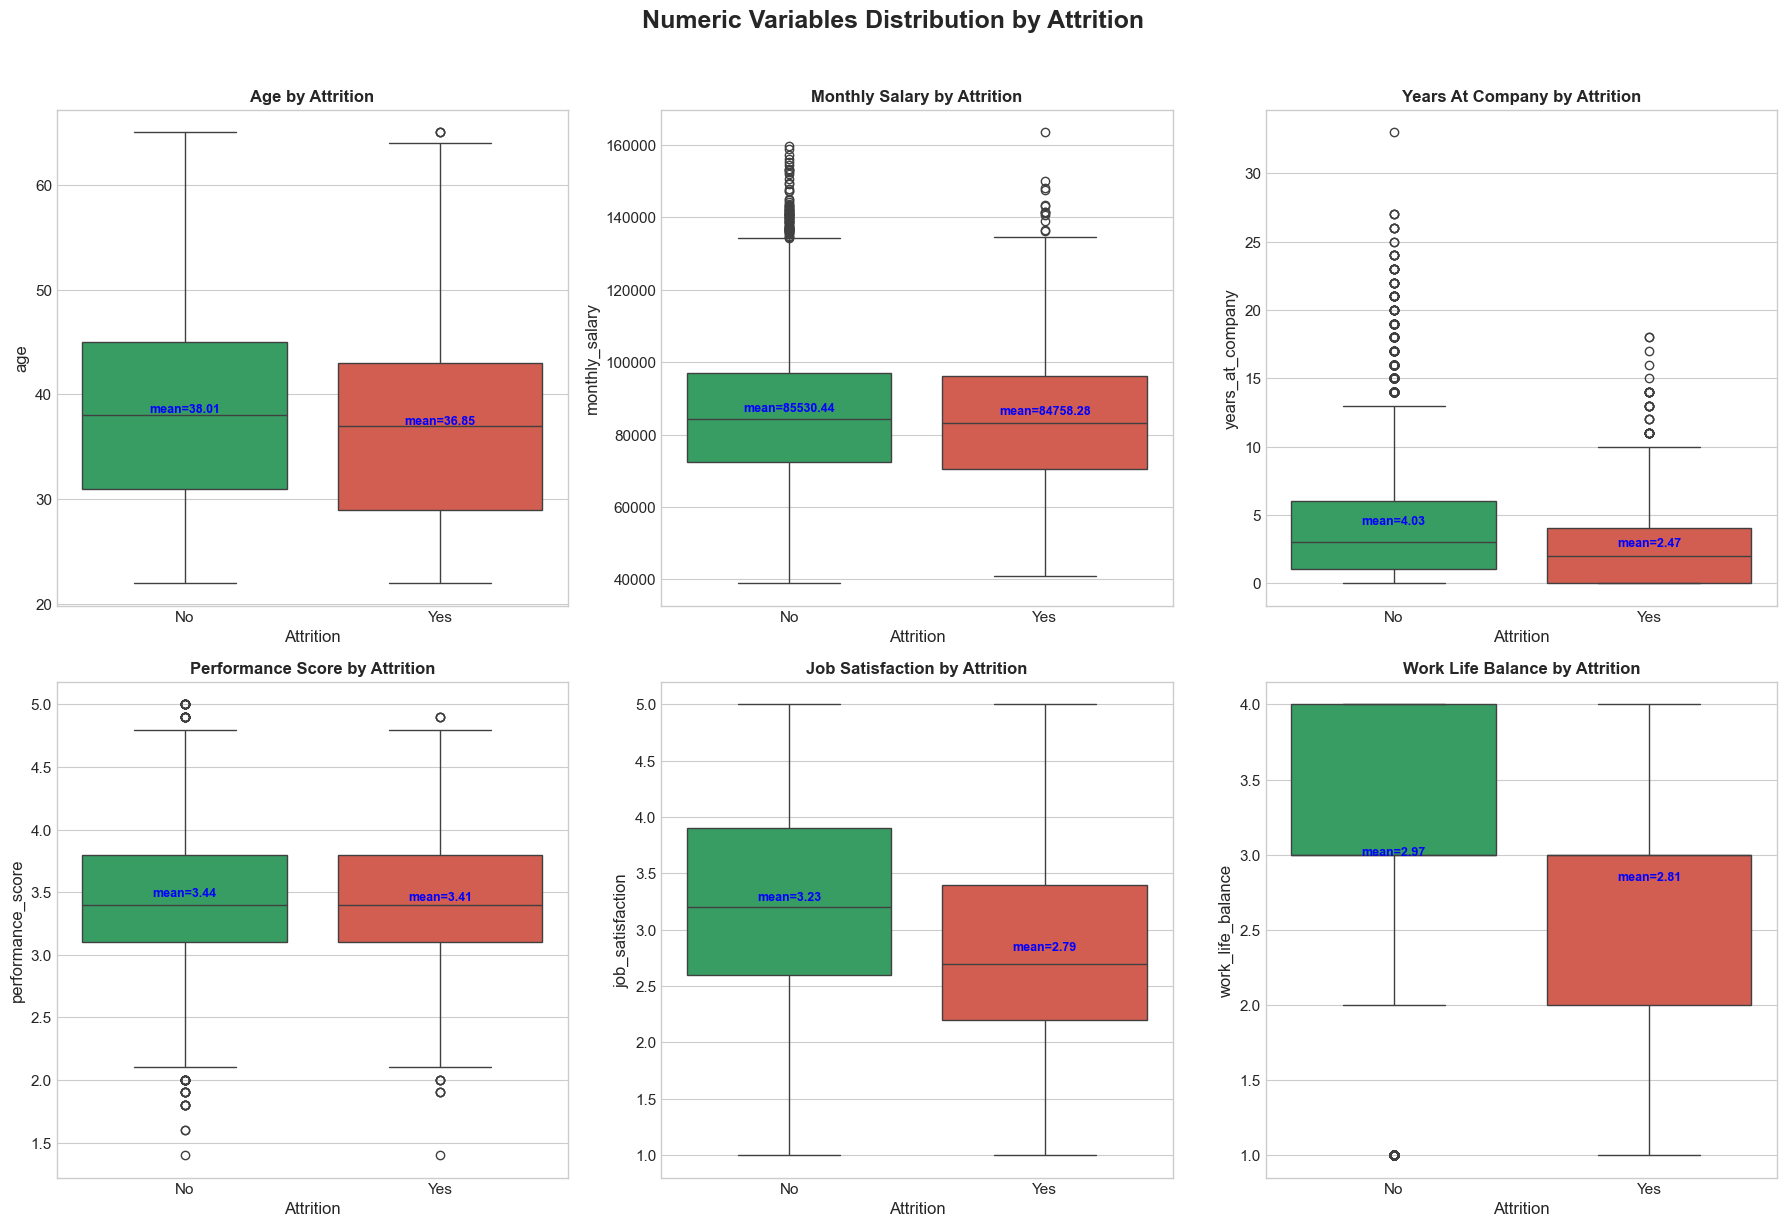

In [21]:
# Numeric variables distribution by Attrition
key_numeric_vars = ['age', 'monthly_salary', 'years_at_company', 'performance_score', 
                    'job_satisfaction', 'work_life_balance']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for ax, col in zip(axes.flatten(), key_numeric_vars):
    sns.boxplot(data=df, x='attrition', y=col, ax=ax, palette=['#27ae60', '#e74c3c'], hue='attrition', legend=False)
    ax.set_title(f'{col.replace("_", " ").title()} by Attrition', fontsize=12, fontweight='bold')
    ax.set_xlabel('Attrition')
    
    # Add means
    means = df.groupby('attrition')[col].mean()
    for i, (att, mean) in enumerate(means.items()):
        ax.text(i, mean, f'mean={mean:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color='blue')

plt.suptitle('Numeric Variables Distribution by Attrition', y=1.02, fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()


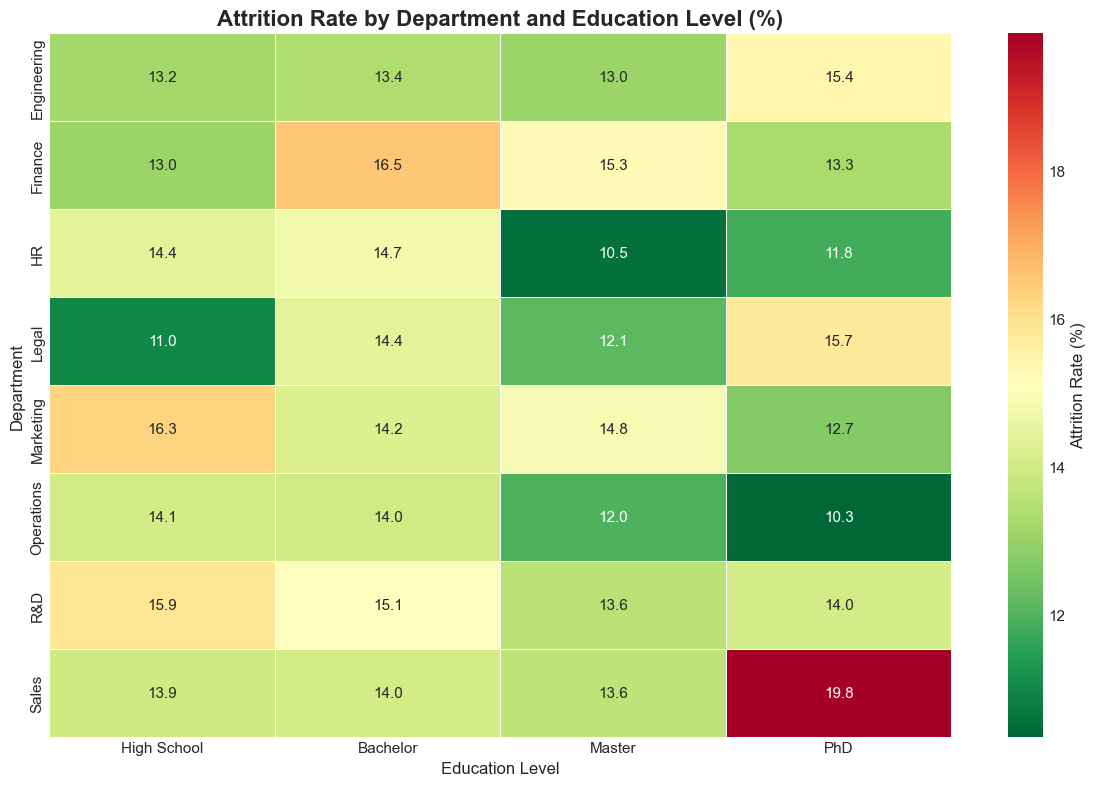

In [22]:
# Heatmap: Attrition by Department and Education Level
fig, ax = plt.subplots(figsize=(12, 8))

pivot_table = df.pivot_table(values='attrition_numeric', index='department', 
                             columns='education', aggfunc='mean') * 100

# Reorder education columns
edu_order = ['High School', 'Bachelor', 'Master', 'PhD']
pivot_table = pivot_table[edu_order]

sns.heatmap(pivot_table, annot=True, fmt='.1f', cmap='RdYlGn_r', 
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Attrition Rate (%)'})

ax.set_title('Attrition Rate by Department and Education Level (%)', fontsize=16, fontweight='bold')
ax.set_xlabel('Education Level')
ax.set_ylabel('Department')

plt.tight_layout()
plt.show()


## 10. Insights and Conclusions


In [23]:
# Executive summary
print("="*80)
print("EXECUTIVE SUMMARY - EXPLORATORY DATA ANALYSIS")
print("="*80)

print(f"\nGENERAL DATASET INFORMATION")
print(f"   - Total employees: {len(df):,}")
print(f"   - Total variables: {len(df.columns)}")
print(f"   - Numeric variables: {len(numeric_cols)}")
print(f"   - Categorical variables: {len(categorical_cols)}")
print(f"   - Null values: {df.isnull().sum().sum()}")
print(f"   - Duplicated rows: {df.duplicated().sum()}")

print(f"\nTARGET VARIABLE (ATTRITION)")
attrition_rate = df['attrition_numeric'].mean() * 100
print(f"   - Attrition rate: {attrition_rate:.2f}%")
print(f"   - Employees who leave: {df['attrition_numeric'].sum():,}")
print(f"   - Employees who stay: {(1-df['attrition_numeric']).sum():,.0f}")

print(f"\nDEMOGRAPHIC PROFILE")
print(f"   - Average age: {df['age'].mean():.1f} years (range: {df['age'].min()}-{df['age'].max()})")
print(f"   - Majority gender: {df['gender'].mode()[0]} ({df['gender'].value_counts(normalize=True).max()*100:.1f}%)")
print(f"   - Most common education: {df['education'].mode()[0]}")

print(f"\nWORK PROFILE")
print(f"   - Average salary: ${df['monthly_salary'].mean():,.0f}")
print(f"   - Salary range: ${df['monthly_salary'].min():,.0f} - ${df['monthly_salary'].max():,.0f}")
print(f"   - Average tenure: {df['years_at_company'].mean():.1f} years")
print(f"   - Average performance score: {df['performance_score'].mean():.2f}")
print(f"   - Employees with overtime: {df['overtime'].value_counts(normalize=True)['Yes']*100:.1f}%")

print(f"\nDEPARTMENTS")
dept_counts = df['department'].value_counts()
print(f"   - Largest department: {dept_counts.index[0]} ({dept_counts.iloc[0]:,} employees)")
print(f"   - Smallest department: {dept_counts.index[-1]} ({dept_counts.iloc[-1]:,} employees)")


EXECUTIVE SUMMARY - EXPLORATORY DATA ANALYSIS

GENERAL DATASET INFORMATION
   - Total employees: 10,000
   - Total variables: 23
   - Numeric variables: 15
   - Categorical variables: 6
   - Null values: 0
   - Duplicated rows: 0

TARGET VARIABLE (ATTRITION)
   - Attrition rate: 14.00%
   - Employees who leave: 1,400
   - Employees who stay: 8,600

DEMOGRAPHIC PROFILE
   - Average age: 37.8 years (range: 22-65)
   - Majority gender: Male (48.7%)
   - Most common education: Bachelor

WORK PROFILE
   - Average salary: $85,422
   - Salary range: $38,957 - $163,489
   - Average tenure: 3.8 years
   - Average performance score: 3.44
   - Employees with overtime: 29.3%

DEPARTMENTS
   - Largest department: Engineering (1,272 employees)
   - Smallest department: Marketing (1,223 employees)


In [24]:
# Key factors identified
print("\n" + "="*80)
print("KEY FACTORS IDENTIFIED")
print("="*80)

# Top correlations with attrition
print("\nSTRONGEST CORRELATIONS WITH ATTRITION:")
for var, corr in target_correlations.head(5).items():
    direction = "Higher" if corr > 0 else "Lower"
    impact = "increases" if corr > 0 else "decreases"
    print(f"   - {var}: {corr:.3f} ({direction} {var} -> {impact} attrition probability)")

# High risk groups
print("\nHIGH RISK GROUPS:")

# By overtime
overtime_risk = df.groupby('overtime')['attrition_numeric'].mean() * 100
if overtime_risk.get('Yes', 0) > overtime_risk.get('No', 0):
    print(f"   - Employees with overtime: {overtime_risk['Yes']:.1f}% attrition vs {overtime_risk['No']:.1f}% without overtime")

# By satisfaction
low_satisfaction = df[df['job_satisfaction'] <= 2]['attrition_numeric'].mean() * 100
high_satisfaction = df[df['job_satisfaction'] >= 4]['attrition_numeric'].mean() * 100
print(f"   - Low job satisfaction (<=2): {low_satisfaction:.1f}% attrition vs {high_satisfaction:.1f}% with high satisfaction (>=4)")

# By department with highest attrition
dept_risk = df.groupby('department')['attrition_numeric'].mean() * 100
high_risk_dept = dept_risk.idxmax()
print(f"   - Highest risk department: {high_risk_dept} ({dept_risk[high_risk_dept]:.1f}% attrition)")



KEY FACTORS IDENTIFIED

STRONGEST CORRELATIONS WITH ATTRITION:
   - job_satisfaction: -0.160 (Lower job_satisfaction -> decreases attrition probability)
   - years_at_company: -0.131 (Lower years_at_company -> decreases attrition probability)
   - num_promotions: -0.080 (Lower num_promotions -> decreases attrition probability)
   - work_life_balance: -0.071 (Lower work_life_balance -> decreases attrition probability)
   - years_in_current_role: -0.070 (Lower years_in_current_role -> decreases attrition probability)

HIGH RISK GROUPS:
   - Employees with overtime: 22.9% attrition vs 10.3% without overtime
   - Low job satisfaction (<=2): 23.5% attrition vs 7.9% with high satisfaction (>=4)
   - Highest risk department: Finance (15.4% attrition)


In [25]:
# Recommendations
print("\n" + "="*80)
print("RECOMMENDATIONS FOR MODELING")
print("="*80)

print("""
1. DATA PREPROCESSING:
   - The dataset is clean (no null values or duplicates)
   - Consider normalization/standardization for numeric variables
   - Apply One-Hot Encoding for categorical variables
   - The 'employee_id' column should be removed before modeling

2. CLASS IMBALANCE:
   - The target variable shows some imbalance
   - Consider techniques: SMOTE, ADASYN, undersampling
   - Use appropriate metrics: F1-Score, AUC-ROC, Precision-Recall

3. FEATURE ENGINEERING:
   - Create ratios: salary/years_experience, projects/year
   - Group satisfaction levels (low, medium, high)
   - Consider variable interactions

4. RECOMMENDED MODELS:
   - Random Forest (good for mixed features)
   - XGBoost/LightGBM (high performance)
   - Logistic Regression (interpretability)

5. IMPORTANT VARIABLES TO INCLUDE:
   - job_satisfaction, environment_satisfaction
   - overtime, work_life_balance
   - years_at_company, years_in_current_role
   - monthly_salary, performance_score
""")



RECOMMENDATIONS FOR MODELING

1. DATA PREPROCESSING:
   - The dataset is clean (no null values or duplicates)
   - Consider normalization/standardization for numeric variables
   - Apply One-Hot Encoding for categorical variables
   - The 'employee_id' column should be removed before modeling

2. CLASS IMBALANCE:
   - The target variable shows some imbalance
   - Consider techniques: SMOTE, ADASYN, undersampling
   - Use appropriate metrics: F1-Score, AUC-ROC, Precision-Recall

3. FEATURE ENGINEERING:
   - Create ratios: salary/years_experience, projects/year
   - Group satisfaction levels (low, medium, high)
   - Consider variable interactions

4. RECOMMENDED MODELS:
   - Random Forest (good for mixed features)
   - XGBoost/LightGBM (high performance)
   - Logistic Regression (interpretability)

5. IMPORTANT VARIABLES TO INCLUDE:
   - job_satisfaction, environment_satisfaction
   - overtime, work_life_balance
   - years_at_company, years_in_current_role
   - monthly_salary, performan

In [26]:
# Clean auxiliary column
df.drop('attrition_numeric', axis=1, inplace=True)

print("\n" + "="*80)
print("EXPLORATORY DATA ANALYSIS COMPLETED")
print("="*80)
print("\nOriginal dataset preserved without permanent modifications.")
print(f"{len(df.columns)} columns available for modeling.")



EXPLORATORY DATA ANALYSIS COMPLETED

Original dataset preserved without permanent modifications.
22 columns available for modeling.
